# Gaming-Player Clustering — How Much Structure Is Really There?

### An unsupervised-learning case study on online-gaming behaviour

**Author:** Blagoy Hristov

---

## Table of contents

1. [Problem understanding, formulation and significance](#sec1)
2. [Mathematical formulation](#sec2)
3. [Data loading and sanity checks](#sec3)
4. [Exploratory data analysis](#sec4)
5. [Feature engineering and preprocessing](#sec5)
6. [Dimensionality and structure check with PCA](#sec6)
7. [K-Means clustering](#sec7)
8. [Choosing *k*: internal validation against a null model](#sec8)
9. [Alternative algorithms: GMM and DBSCAN](#sec9)
10. [External validation and cluster profiling](#sec10)
11. [Conclusions, limitations and future work](#sec11)
12. [References](#refs)

## How to reproduce

```bash
python -m pip install -r requirements.txt
jupyter lab   # then: Kernel ▸ Restart Kernel and Run All Cells
```

**Reproducibility conventions used throughout**

* Every stochastic step is seeded with `random_state = 42`.
* The dataset lives in `data/online_gaming_behavior_dataset.csv`; reusable
  helpers live in `src/clustering_utils.py`.
* The notebook is designed to run top-to-bottom with **Restart & Run All**;
  each cell depends only on cells above it.

<a id="sec1"></a>
## 1. Problem understanding, formulation and significance

### 1.1 The real-world problem

Online games generate rich behavioural logs: how often a player plays, how long
their sessions last, how far they progress, whether they spend money, and so on.
A recurring task in **game analytics** is *player segmentation* — grouping
players with similar behaviour so that product and marketing teams can act on
each group differently:

* **Retention** — detect at-risk (low-engagement) players early and target them
  with re-engagement campaigns.
* **Monetisation** — distinguish spenders from non-spenders and tailor offers.
* **Matchmaking / game design** — balance content for casual vs. hardcore
  populations.

Segmentation is attractive because it turns a formless mass of users into a
small number of actionable groups. The catch — and the theme of this project —
is that segmentation is only meaningful **if the groups actually exist**.

### 1.2 Significance and prior approaches

Player segmentation is a special case of **customer segmentation**, a
decades-old problem in marketing analytics. Well-known approaches include:

| Approach | Idea | Pros | Cons |
|---|---|---|---|
| **RFM analysis** | Rank users by Recency, Frequency, Monetary value | Simple, interpretable, no ML needed | Hand-picked features; arbitrary bins; ignores other behaviour |
| **K-Means clustering** | Partition standardised features into $k$ spherical groups | Fast, scalable, well understood | Must pre-specify $k$; assumes convex, equal-spread clusters; sensitive to scaling |
| **Gaussian Mixture Models** | Soft, elliptical clusters via a probabilistic model | Flexible shapes; soft assignments; principled model selection (BIC) | More parameters; can over-fit; still assumes a mixture exists |
| **Density-based (DBSCAN)** | Clusters = dense regions separated by sparse ones | Finds arbitrary shapes; labels outliers; no $k$ needed | Very sensitive to `eps`; struggles in high dimensions and uniform density |

All of these methods **will always return an answer** — they will happily
partition even structureless data. The scientific burden is therefore on the
analyst to **validate** that the returned partition reflects real structure.

### 1.3 From the real-world problem to a mathematical one

Formally, we are given $n$ players, each a vector
$\mathbf{x}_i \in \mathbb{R}^{p}$ of $p$ numeric behavioural features. Clustering
seeks a partition of the players into $K$ disjoint groups
$C_1, \dots, C_K$ such that players within a group are "similar" and players in
different groups are "dissimilar", where similarity is measured by a distance
(here, Euclidean distance in standardised feature space). This is an
**unsupervised** problem: there is no ground-truth grouping to fit to.

### 1.4 The dataset — and an honest caveat stated up front

We use the public **"Predict Online Gaming Behavior"** dataset (Kaggle [1];
see [References](#refs)), containing 40&nbsp;034 players and 13 columns.

**Important caveat, declared before any modelling.** As Section&nbsp;4 will show
empirically, this dataset is almost certainly **synthetically generated**: its
numeric features are near-uniform on fixed ranges and **mutually independent**
(all pairwise correlations $< 0.01$). Real behavioural data is heavy-tailed and
correlated (heavy players tend to play more *and* progress further). We do
**not** hide this behind persona-hunting. Instead we let it *define* the
research question.

### 1.5 Research question, scope and assumptions

> **Research question.** *How much genuine cluster structure exists in these
> player features — and if the labelled `EngagementLevel` is the only structure,
> where does it live and can unsupervised methods recover it?*

**Objectives.**
1. Quantify how much (if any) natural cluster structure the behavioural
   features contain, using internal indices validated against a null model.
2. Diagnose the geometry of the data (independence, uniformity) with PCA.
3. Test whether clustering can recover the known `EngagementLevel` label, and
   explain the result through the lens of **feature selection / noise
   dimensions**.

**Scope & constraints.**
* We cluster on **numeric behavioural features only**; categorical and binary
  attributes are used for *post-hoc profiling*, not distance computation
  (justified in Section&nbsp;5).
* `EngagementLevel` is treated as a held-out **label for external validation**,
  never as a clustering input.
* Assumptions: features are on interval scales after standardisation; Euclidean
  distance is a reasonable dissimilarity for standardised numeric data.

<a id="sec2"></a>
## 2. Mathematical formulation

### 2.1 Notation and standardisation

Let the data matrix be $X \in \mathbb{R}^{n\times p}$ with rows
$\mathbf{x}_i=(x_{i1},\dots,x_{ip})$, $i=1,\dots,n$. Because our features have
very different units (minutes vs. counts vs. levels), we **standardise** each
feature $j$ to zero mean and unit variance (a *z-score*):

$$
z_{ij}=\frac{x_{ij}-\mu_j}{\sigma_j},\qquad
\mu_j=\frac1n\sum_{i=1}^n x_{ij},\qquad
\sigma_j=\sqrt{\frac1n\sum_{i=1}^n (x_{ij}-\mu_j)^2}.
$$

Standardisation matters because K-Means uses Euclidean distance, which is
dominated by whichever feature has the largest raw spread. After scaling, every
feature contributes on an equal footing.

### 2.2 Dissimilarity: Euclidean distance

For two standardised points $\mathbf{a},\mathbf{b}\in\mathbb{R}^p$,

$$
d(\mathbf{a},\mathbf{b})=\lVert \mathbf{a}-\mathbf{b}\rVert_2
=\sqrt{\sum_{j=1}^{p}(a_j-b_j)^2}.
$$

### 2.3 K-Means and the within-cluster sum of squares (WCSS)

Given a target number of clusters $K$, K-Means partitions the points into
$C_1,\dots,C_K$ with centroids $\boldsymbol{\mu}_1,\dots,\boldsymbol{\mu}_K$ to
**minimise the within-cluster sum of squares** (also called *inertia*):

$$
J(\{C_k\},\{\boldsymbol{\mu}_k\})
=\sum_{k=1}^{K}\sum_{\mathbf{x}_i\in C_k}\lVert \mathbf{x}_i-\boldsymbol{\mu}_k\rVert_2^2,
\qquad
\boldsymbol{\mu}_k=\frac{1}{|C_k|}\sum_{\mathbf{x}_i\in C_k}\mathbf{x}_i .
$$

**Lloyd's algorithm** [2] minimises $J$ by alternating two steps until
assignments stop changing:

1. **Assignment.** Assign each point to its nearest centroid:
   $\;c_i=\arg\min_k \lVert \mathbf{x}_i-\boldsymbol{\mu}_k\rVert_2^2.$
2. **Update.** Recompute each centroid as the mean of its assigned points.

Each step never increases $J$, so the algorithm converges — but only to a
**local** optimum. **k-means++** seeding [3] reduces this risk by choosing
initial centroids spread apart: the first centre is random, and each subsequent centre
is chosen with probability proportional to $D(\mathbf{x})^2$, the squared
distance to the nearest already-chosen centre. We run several seeded restarts
(`n_init=10`) and keep the best.

### 2.4 Internal validation indices

Because there is no ground truth, we judge a partition with several
*internal* indices.

**Silhouette** (Rousseeuw, 1987 [6]). For point $i$ let $a(i)$ be its mean
distance to other points **in its own cluster** and $b(i)$ the mean distance to
points in the **nearest other cluster**. Then

$$
s(i)=\frac{b(i)-a(i)}{\max\{a(i),b(i)\}}\in[-1,1].
$$

Values near $1$ mean well-separated clusters; values near $0$ mean overlapping
clusters (points sit on the boundary). We report the mean $s(i)$. For
well-separated, roughly convex clusters the mean silhouette *tends to* peak near
the true number of clusters — a useful heuristic, not a guarantee (it can fail
for nested or elongated structure).

**Davies–Bouldin index** [7] — average worst-case ratio of within-cluster
scatter to between-centroid distance; **lower is better**:
$$
\mathrm{DB}=\frac1K\sum_{k=1}^{K}\max_{l\neq k}
\frac{S_k+S_l}{d(\boldsymbol{\mu}_k,\boldsymbol{\mu}_l)},
$$
where $S_k$ is the mean distance of cluster $k$'s points to $\boldsymbol{\mu}_k$.

**Calinski–Harabasz index** [8] — the variance-ratio criterion
$$
\mathrm{CH}=\frac{\operatorname{tr}(B)\,/\,(K-1)}{\operatorname{tr}(W)\,/\,(n-K)},
$$
where $B$ and $W$ are the between- and within-cluster scatter matrices; it is a
*per-degree-of-freedom* variance ratio and **higher is better**. The
$(n-K)/(K-1)$ factor is partly why CH tends to fall as $K$ grows.

**The null-model idea (crucial).** Every index above still returns a number for
structureless data. To interpret it we compare against a **Monte-Carlo null
model**: independent uniform features of the same shape, standardised and
clustered identically. If the real data's silhouette matches the null's, the
"clusters" carry no more structure than a random slicing of a uniform cloud.

### 2.5 External validation: the Adjusted Rand Index

When a reference labelling *is* available (here `EngagementLevel`), we compare it
to a clustering with the **Adjusted Rand Index** [9]. Given the contingency table
$n_{ij}$ of cluster $i$ vs. class $j$ (with row/column sums $a_i,b_j$),

$$
\mathrm{ARI}=
\frac{\sum_{ij}\binom{n_{ij}}{2}-\dfrac{\sum_i\binom{a_i}{2}\sum_j\binom{b_j}{2}}{\binom{n}{2}}}
{\tfrac12\!\left[\sum_i\binom{a_i}{2}+\sum_j\binom{b_j}{2}\right]-\dfrac{\sum_i\binom{a_i}{2}\sum_j\binom{b_j}{2}}{\binom{n}{2}}}.
$$

ARI is **corrected for chance**: it is $0$ for random agreement and $1$ for a
perfect match, so an ARI near $0$ is strong evidence that a clustering has *not*
recovered the reference labels.

### 2.6 PCA and Gaussian Mixture Models (used later)

**PCA.** Principal Component Analysis diagonalises the covariance matrix
$\Sigma=\frac1n Z^\top Z$ of the *mean-centred* standardised data $Z$
(scikit-learn uses the $\tfrac{1}{n-1}$ divisor instead, which changes neither
the eigenvectors nor the variance ratios); its eigenvectors are the principal
axes and the eigenvalues $\lambda_1\ge\dots\ge\lambda_p$ give the variance along
each. The **explained-variance ratio** $\lambda_j/\sum_l\lambda_l$ tells us how
compressible the data is. For $p$ *uncorrelated* standardised features the
correlation matrix is $\approx I$, so every $\lambda_j\approx 1$ and the ratios
are all $\approx 1/p$ — a flat scree plot. Note this detects only *linear*
redundancy; the null-model and density checks below are what rule out non-linear
clumping.

**GMM.** A Gaussian Mixture models the density as
$p(\mathbf{x})=\sum_{k=1}^{K}\pi_k\,\mathcal N(\mathbf{x}\mid\boldsymbol\mu_k,\Sigma_k)$,
fitted by Expectation–Maximisation [4]. Model order $K$ is chosen with the
**Bayesian Information Criterion** [10] $\mathrm{BIC}=-2\ln\hat L + m\ln n$ (with
$m$ free parameters); lower is better, and a genuine mixture shows a clear BIC
minimum.

<a id="sec3"></a>
## 3. Data loading and sanity checks

We load the dataset and run basic integrity checks (shape, types, missing
values, duplicates, and identifier uniqueness) before any analysis.

In [1]:
import sys
sys.path.insert(0, "src")  # make the reusable helper module importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

import clustering_utils as cu

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
cu.set_plot_style()

pd.set_option("display.max_columns", 20)
print("Libraries loaded. NumPy", np.__version__, "| pandas", pd.__version__)

Libraries loaded. NumPy 2.2.2 | pandas 2.2.3


In [2]:
df = pd.read_csv("data/online_gaming_behavior_dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [4]:
# Integrity checks
print("Missing values per column:")
print(df.isna().sum().to_string())
print("\nDuplicate rows          :", int(df.duplicated().sum()))
print("Duplicate PlayerID values:", int(df["PlayerID"].duplicated().sum()))

Missing values per column:
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0

Duplicate rows          : 0


Duplicate PlayerID values: 0


In [5]:
# Summary statistics of the numeric columns
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PlayerID,40034.0,29016.50,11556.96,9000.0,19008.25,29016.50,39024.75,49033.0
Age,40034.0,31.99,10.04,15.0,23.00,32.00,41.00,49.0
PlayTimeHours,40034.0,12.02,6.91,0.0,6.07,12.01,17.96,24.0
InGamePurchases,40034.0,0.20,0.40,0.0,0.00,0.00,0.00,1.0
SessionsPerWeek,40034.0,9.47,5.76,0.0,4.00,9.00,14.00,19.0
AvgSessionDurationMinutes,40034.0,94.79,49.01,10.0,52.00,95.00,137.00,179.0
PlayerLevel,40034.0,49.66,28.59,1.0,25.00,49.00,74.00,99.0
AchievementsUnlocked,40034.0,24.53,14.43,0.0,12.00,25.00,37.00,49.0


**Sanity-check verdict.** The dataset is exceptionally clean: 40&nbsp;034 rows,
no missing values, no duplicate rows and a unique `PlayerID`. The `describe`
table already hints at the caveat from Section&nbsp;1 — every numeric feature
has a mean sitting almost exactly at the midpoint of its range (e.g. `Age`
$\approx 32$ on $[15,49]$, `PlayerLevel` $\approx 50$ on $[1,99]$), the signature
of a **uniform** distribution. We test this properly next.

<a id="sec4"></a>
## 4. Exploratory data analysis

The EDA has one central goal: characterise the *geometry* of the data. Three
questions drive it — (a) how are individual features distributed? (b) are
features correlated? (c) what, if anything, distinguishes the `EngagementLevel`
classes?

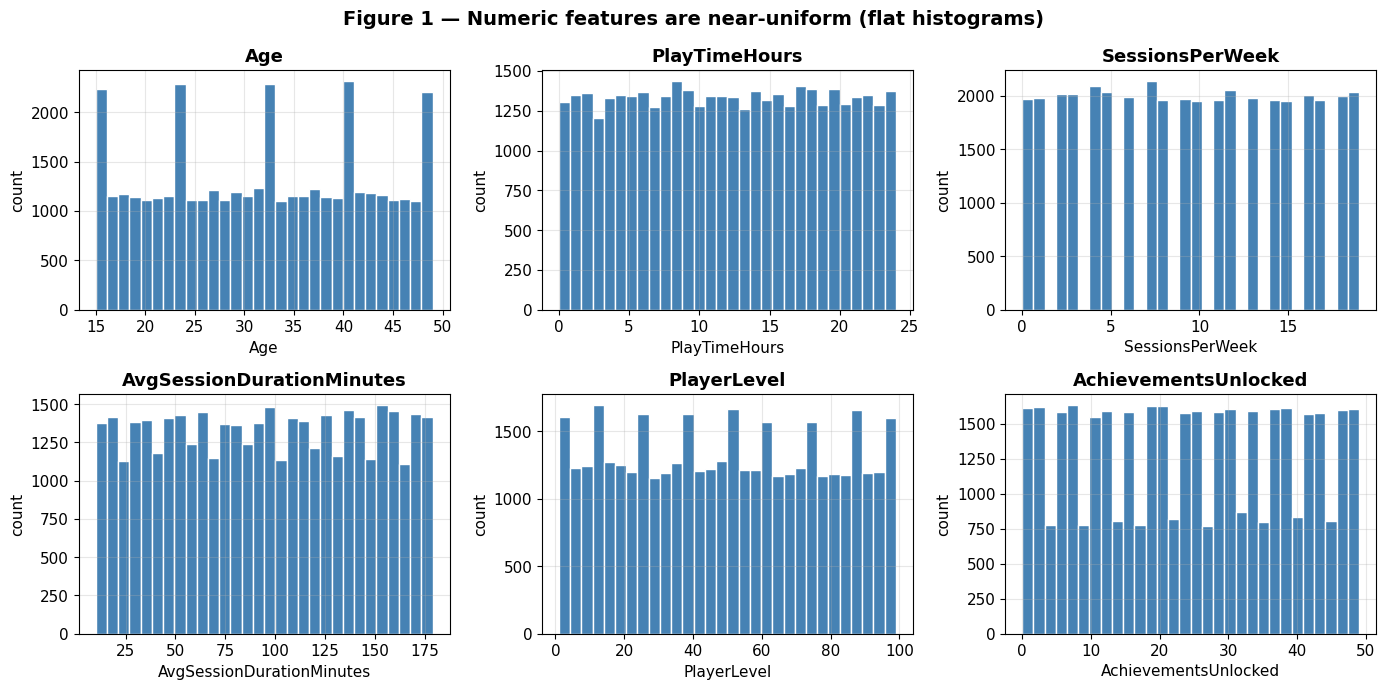

In [6]:
numeric_features = ["Age", "PlayTimeHours", "SessionsPerWeek",
                    "AvgSessionDurationMinutes", "PlayerLevel", "AchievementsUnlocked"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), numeric_features):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col); ax.set_ylabel("count")
fig.suptitle("Figure 1 — Numeric features are near-uniform (flat histograms)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**Figure 1.** Every numeric feature is essentially **flat / uniform** over its
range — there are no modes, no gaps, no skew. Real engagement metrics are almost
always right-skewed (a few very heavy users). Uniform histograms are the first
strong sign of synthetic, structureless data.

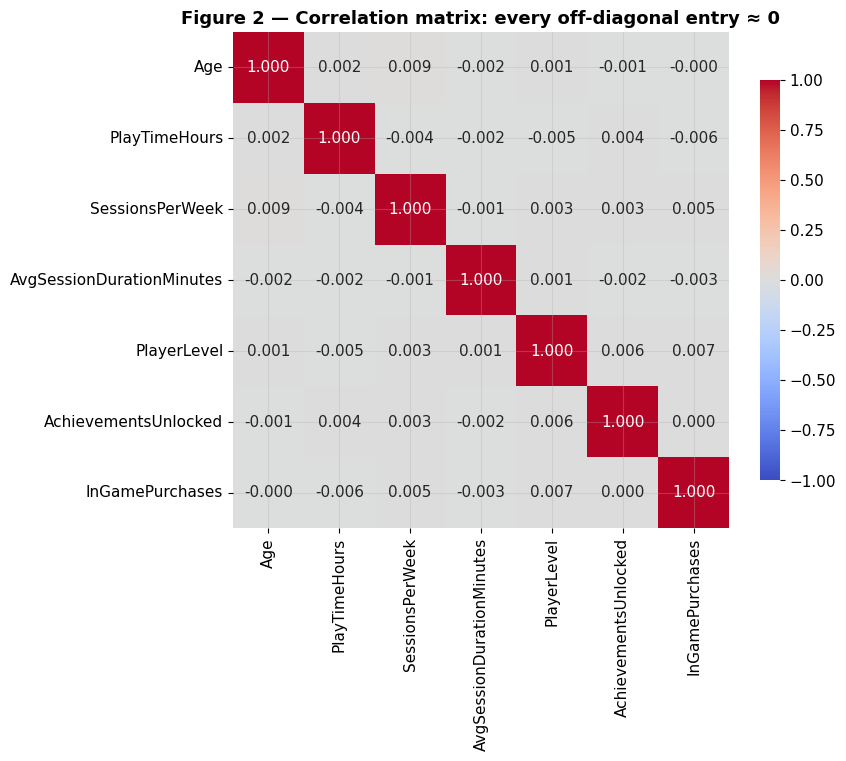

Maximum absolute off-diagonal correlation: 0.0088


In [7]:
# Correlation among numeric behavioural + demographic features (exclude PlayerID)
corr_cols = numeric_features + ["InGamePurchases"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Figure 2 — Correlation matrix: every off-diagonal entry ≈ 0")
plt.show()

off_diag = corr.to_numpy()[~np.eye(len(corr), dtype=bool)]
print(f"Maximum absolute off-diagonal correlation: {np.abs(off_diag).max():.4f}")

**Figure 2.** The largest absolute correlation between any two features is about
**0.009** — effectively zero, so the features are **mutually uncorrelated** (the
correlation matrix is $\approx I$). Together with the near-uniform marginals of
Figure&nbsp;1, this means there is no *linear* low-dimensional structure for PCA
to compress and no correlated "directions" for clusters to form along. (Strict
independence is stronger than zero correlation; the null-model and density tests
in Sections&nbsp;8–9 close that gap by ruling out non-linear structure too.)

In [8]:
# Categorical distributions
categorical_features = ["Gender", "Location", "GameGenre", "GameDifficulty", "EngagementLevel"]
for col in categorical_features:
    counts = df[col].value_counts()
    print(f"{col}:")
    print(counts.to_string())
    print()

Gender:
Gender
Male      23959
Female    16075

Location:
Location
USA       16000
Europe    12004
Asia       8095
Other      3935

GameGenre:
GameGenre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952

GameDifficulty:
GameDifficulty
Easy      20015
Medium    12011
Hard       8008

EngagementLevel:
EngagementLevel
Medium    19374
High      10336
Low       10324



,Age,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
EngagementLevel,,,,,,
Low,31.90,12.10,4.53,66.88,46.10,22.66
Medium,32.08,11.96,9.55,89.86,50.93,25.22
High,31.92,12.07,14.25,131.92,50.82,25.10


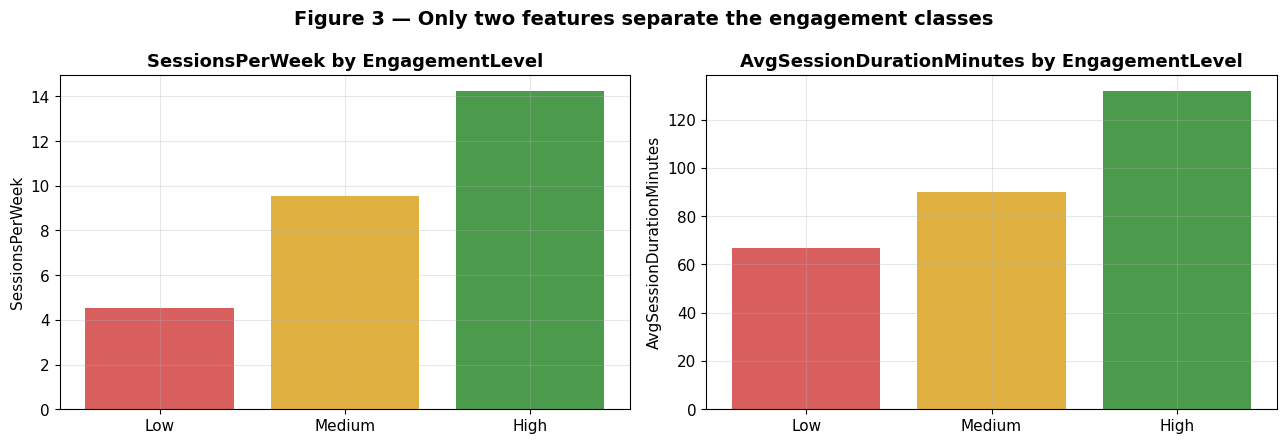

In [9]:
# What separates the EngagementLevel classes? Compare per-class means.
order = ["Low", "Medium", "High"]
group_means = df.groupby("EngagementLevel")[numeric_features].mean().loc[order].round(2)
display(group_means)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, col in zip(axes, ["SessionsPerWeek", "AvgSessionDurationMinutes"]):
    ax.bar(order, group_means[col].values, color=["#d95f5f", "#e0b040", "#4c9a4c"])
    ax.set_title(f"{col} by EngagementLevel")
    ax.set_ylabel(col)
fig.suptitle("Figure 3 — Only two features separate the engagement classes",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

**Figure 3 & table.** This is the key EDA finding. Across the three engagement
classes, **only two features change**:

* `SessionsPerWeek`: ~4.5 (Low) → ~9.6 (Medium) → ~14.3 (High)
* `AvgSessionDurationMinutes`: ~67 → ~90 → ~132

Every other feature is essentially flat across classes (a *faint* secondary
gradient appears in `PlayerLevel`/`AchievementsUnlocked` for the Low group, but
it is small). In other words, `EngagementLevel` is — by construction — a
**deterministic threshold on two features**, not an emergent property of the
whole behavioural profile. We will exploit this fact in Section&nbsp;10.

<a id="sec5"></a>
## 5. Feature engineering and preprocessing

### 5.1 Which features enter the clustering — and why

We cluster on the **numeric behavioural** features only:

`PlayTimeHours`, `SessionsPerWeek`, `AvgSessionDurationMinutes`,
`PlayerLevel`, `AchievementsUnlocked`.

Deliberate exclusions, each justified:

* **`PlayerID`** — an identifier, carries no behaviour.
* **`Age`** — a *demographic*, not a behaviour; we keep it for profiling.
* **`EngagementLevel`** — the label we will validate against; using it as an
  input would be circular.
* **Categorical features** (`Gender`, `Location`, `GameGenre`,
  `GameDifficulty`) — nominal; one-hot encoding them and dropping them into
  Euclidean distance would impose an arbitrary geometry. Kept for profiling.
* **`InGamePurchases`** (binary 0/1) — **excluded from distance on purpose.**
  Standardisation equalises variance, so a z-scored binary does *not* have a
  larger spread than the other features — that is not the objection. The problem
  is that it collapses to a single **dominant discrete axis** taking only two
  values (≈ $+2.0$ for the ~20% minority, ≈ $-0.5$ for the majority). Every
  spender then sits a *fixed* squared gap of $(2.0-(-0.5))^2\approx 6$ from every
  non-spender, against an expected ≈ 2 baseline gap between two independent
  unit-variance points, so clusters would tend to split on purchase status — a
  nominal flag masquerading as a metric coordinate. Binary flags belong in
  post-hoc profiling, not in the distance.

### 5.2 One engineered feature

We derive **`TotalWeeklyMinutes` = `SessionsPerWeek` × `AvgSessionDurationMinutes`**
— total time invested per week. It is created *before* scaling. We hold it *out*
of the primary clustering matrix (to keep "does raw behaviour cluster?" separate
from a hand-crafted signal axis) and use it in Section&nbsp;10 to probe where the
engagement signal lives.

In [10]:
# Feature engineering: total weekly minutes (created before scaling)
df["TotalWeeklyMinutes"] = df["SessionsPerWeek"] * df["AvgSessionDurationMinutes"]

print("TotalWeeklyMinutes - mean by EngagementLevel:")
print(df.groupby("EngagementLevel")["TotalWeeklyMinutes"].mean().loc[order].round(1).to_string())

TotalWeeklyMinutes - mean by EngagementLevel:
EngagementLevel
Low        219.8
Medium     734.7
High      1880.3


In [11]:
# Primary clustering feature set + standardisation (z-score)
BEHAVIORAL = ["PlayTimeHours", "SessionsPerWeek", "AvgSessionDurationMinutes",
              "PlayerLevel", "AchievementsUnlocked"]

def scale(columns):
    """z-score the given columns of `df` and return a NumPy array."""
    return StandardScaler().fit_transform(df[columns].to_numpy())

X = scale(BEHAVIORAL)

# Assert the scaling did what we expect: ~0 mean, ~1 std on every column
assert np.allclose(X.mean(axis=0), 0, atol=1e-9), "columns are not mean-centred"
assert np.allclose(X.std(axis=0), 1, atol=1e-9),  "columns are not unit-variance"
print(f"Standardised feature matrix X: shape {X.shape}, "
      f"mean ~ {X.mean():.1e}, std ~ {X.std():.3f}")

Standardised feature matrix X: shape (40034, 5), mean ~ 1.7e-17, std ~ 1.000


The assertions confirm every clustering feature now has mean $\approx 0$ and
standard deviation $\approx 1$, so no single feature can dominate the Euclidean
distance by scale alone. `X` (40&nbsp;034 × 5) is our clustering input from here on.

<a id="sec6"></a>
## 6. Dimensionality and structure check with PCA

Before clustering we use PCA as a **structure detector**. If the data lived on a
lower-dimensional manifold (correlated features), the first few principal
components would capture most of the variance. Given the near-zero correlations
of Section&nbsp;4, we *predict* a flat scree plot — a falsifiable prediction.

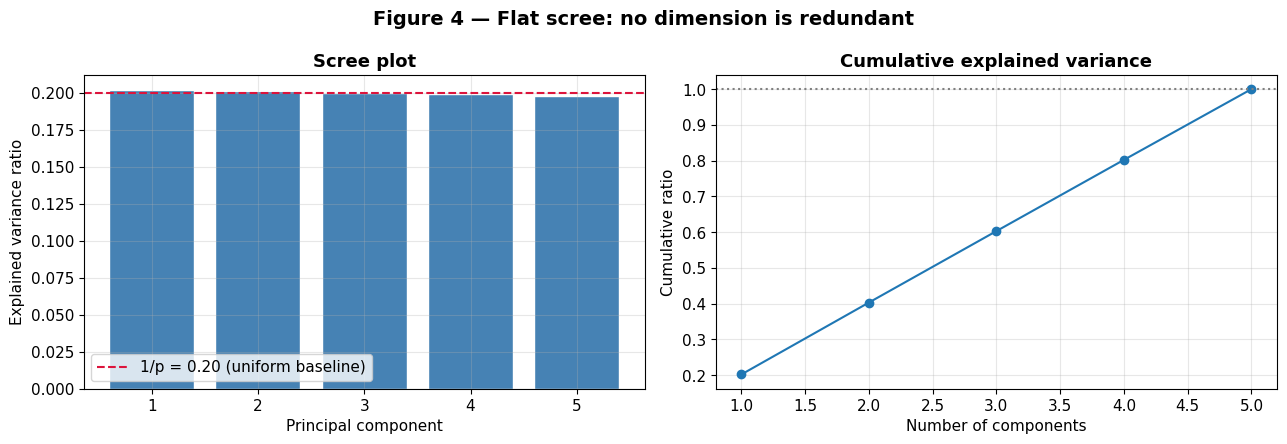

Explained variance ratio: [0.2019 0.2011 0.1999 0.1993 0.1978]
First two components explain only 40.3% of the variance.


In [12]:
pca = PCA(random_state=RANDOM_STATE).fit(X)
evr = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(1, len(evr) + 1), evr, color="steelblue", edgecolor="white")
axes[0].axhline(1 / X.shape[1], color="crimson", ls="--",
                label=f"1/p = {1 / X.shape[1]:.2f} (uniform baseline)")
axes[0].set_title("Scree plot"); axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio"); axes[0].legend()

axes[1].plot(range(1, len(evr) + 1), np.cumsum(evr), marker="o")
axes[1].axhline(1.0, color="grey", ls=":")
axes[1].set_title("Cumulative explained variance")
axes[1].set_xlabel("Number of components"); axes[1].set_ylabel("Cumulative ratio")
fig.suptitle("Figure 4 — Flat scree: no dimension is redundant",
             fontsize=14, fontweight="bold")
fig.tight_layout(); plt.show()

print("Explained variance ratio:", np.round(evr, 4))
print("First two components explain only "
      f"{evr[:2].sum() * 100:.1f}% of the variance.")

**Figure 4.** The prediction holds exactly. Each of the five components explains
almost precisely $1/5 = 20\%$ of the variance, and the first two together reach
only ~40%. **PCA cannot compress this data at all** — the tell-tale fingerprint
of independent features. Consequently we do *not* reduce dimensionality for
modelling; PCA is used **only for 2-D visualisation** below, and clustering is
performed in the full standardised space.

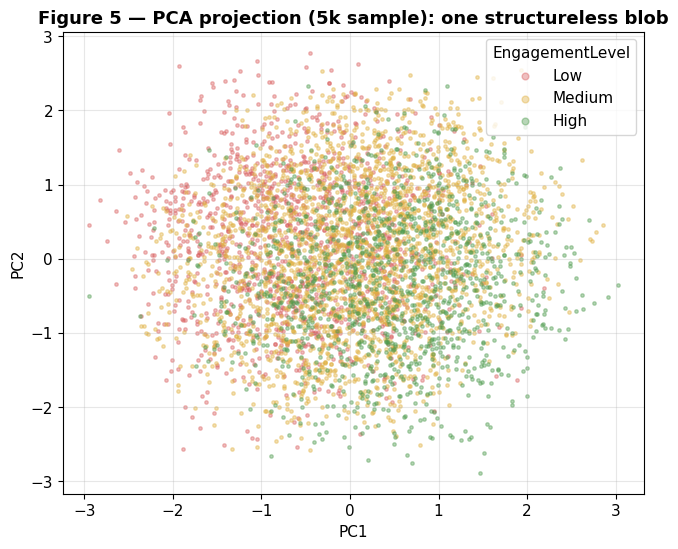

In [13]:
# 2-D PCA projection for visualisation only (coloured by the known label)
Z2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X)
sample = np.random.RandomState(RANDOM_STATE).choice(len(Z2), size=5000, replace=False)

fig, ax = plt.subplots(figsize=(7.5, 6))
palette = {"Low": "#d95f5f", "Medium": "#e0b040", "High": "#4c9a4c"}
for level in order:
    m = (df["EngagementLevel"].to_numpy()[sample] == level)
    ax.scatter(Z2[sample][m, 0], Z2[sample][m, 1], s=6, alpha=0.4,
               color=palette[level], label=level)
ax.set_title("Figure 5 — PCA projection (5k sample): one structureless blob")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(title="EngagementLevel", markerscale=2)
plt.show()

**Figure 5.** Projected onto its first two components the data is a single,
featureless blob with no visible gaps or islands, and the engagement classes are
thoroughly intermixed — the label is *not* separable in this projection. This
foreshadows the negative clustering result.

<a id="sec7"></a>
## 7. K-Means clustering

We now apply K-Means (Section&nbsp;2.3) in the full standardised space. To make
the mechanics concrete we first fit a single model with $k=3$ (matching the three
engagement classes) and inspect it; Section&nbsp;8 then sweeps $k$ properly.

In [14]:
km3 = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(X)
print("Inertia (WCSS) at k=3:", round(km3.inertia_, 1))
print("\nCluster sizes:")
print(pd.Series(km3.labels_).value_counts().sort_index().to_string())

Inertia (WCSS) at k=3: 151698.1

Cluster sizes:
0    12773
1    14871
2    12390


K-Means converges without trouble and returns three clusters of comparable
size. That is *not* evidence of structure — K-Means will always return $k$
non-empty groups. The centroids simply carve the uniform blob into three
roughly equal Voronoi cells. The real question is whether **any** $k$ produces a
partition that is meaningfully better than chance, which we address next.

<a id="sec8"></a>
## 8. Choosing *k*: internal validation against a null model

We sweep $k = 2,\dots,10$ and record four internal indices (Section&nbsp;2.4):
inertia (for the elbow heuristic), silhouette, Davies–Bouldin and
Calinski–Harabasz. Crucially, we also compute the **silhouette of a uniform-
random null model** of the same shape and overlay it — this is what turns a
vague "the scores look low" into a rigorous comparison.

In [15]:
k_values = range(2, 11)
metrics = cu.kmeans_selection(X, k_values, random_state=RANDOM_STATE)

# Monte-Carlo null band: 20 uniform-random datasets of the same shape as X,
# clustered identically. This gives the null a *distribution*, not one draw.
null_band = cu.null_silhouette_band(X.shape, k_values, n_draws=20,
                                    random_state=RANDOM_STATE)

# Does the real silhouette fall inside the null band at every k?
comparison = metrics[["silhouette"]].join(null_band)
comparison["inside_band"] = comparison["silhouette"].between(
    comparison["null_min"], comparison["null_max"])
comparison.round(4)

,silhouette,null_mean,null_min,null_max,null_std,inside_band
k,,,,,,
2,0.1498,0.1485,0.1466,0.1515,0.0012,True
3,0.1346,0.1359,0.1339,0.1373,0.0009,True
4,0.1426,0.1423,0.1398,0.1451,0.0012,True
5,0.1465,0.1456,0.1424,0.1482,0.0016,True
6,0.1500,0.1510,0.1478,0.1538,0.0013,True
7,0.1512,0.1522,0.1478,0.1549,0.0020,True
8,0.1593,0.1602,0.1557,0.1649,0.0026,True
9,0.1626,0.1631,0.1602,0.1663,0.0017,True
10,0.1686,0.1702,0.1678,0.1744,0.0016,True


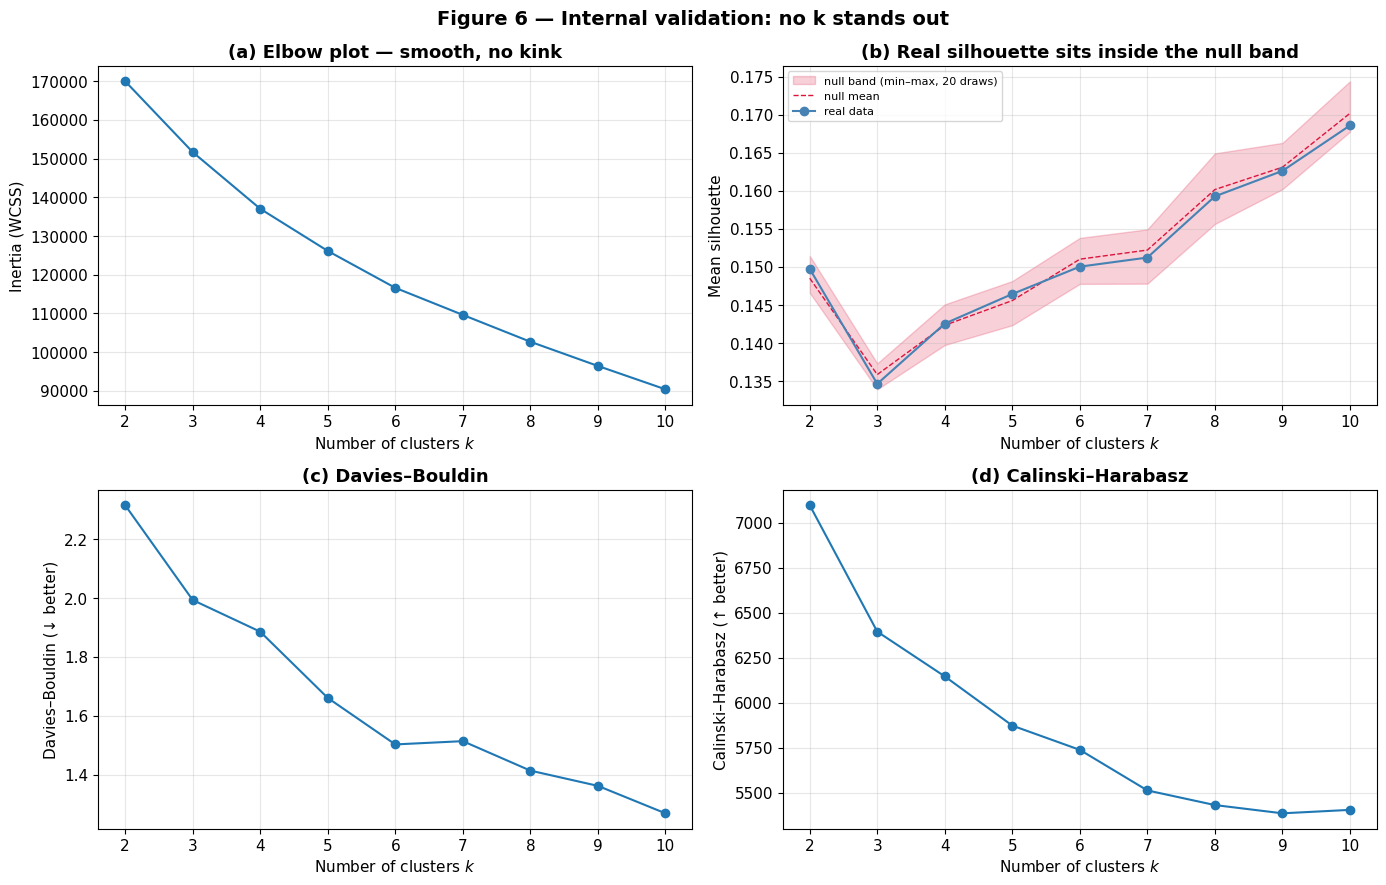

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) Elbow
cu.plot_metric_vs_k(metrics, "inertia", "Inertia (WCSS)",
                    "(a) Elbow plot — smooth, no kink", ax=axes[0, 0])

# (b) Silhouette vs the Monte-Carlo null band
axes[0, 1].fill_between(null_band.index, null_band["null_min"], null_band["null_max"],
                        color="crimson", alpha=0.20,
                        label="null band (min–max, 20 draws)")
axes[0, 1].plot(null_band.index, null_band["null_mean"], ls="--", lw=1,
                color="crimson", label="null mean")
axes[0, 1].plot(metrics.index, metrics["silhouette"], marker="o",
                color="steelblue", label="real data")
axes[0, 1].set_title("(b) Real silhouette sits inside the null band")
axes[0, 1].set_xlabel("Number of clusters $k$"); axes[0, 1].set_ylabel("Mean silhouette")
axes[0, 1].legend(fontsize=8)

# (c) Davies-Bouldin (lower better)
cu.plot_metric_vs_k(metrics, "davies_bouldin", "Davies–Bouldin (↓ better)",
                    "(c) Davies–Bouldin", ax=axes[1, 0])

# (d) Calinski-Harabasz (higher better)
cu.plot_metric_vs_k(metrics, "calinski_harabasz", "Calinski–Harabasz (↑ better)",
                    "(d) Calinski–Harabasz", ax=axes[1, 1])

fig.suptitle("Figure 6 — Internal validation: no k stands out",
             fontsize=14, fontweight="bold")
fig.tight_layout(); plt.show()

**Figure 6 — the heart of the negative result.**

* **(a) Elbow.** Inertia falls smoothly with no kink; there is no "elbow" $k$ at
  which adding clusters stops helping. (A smooth, convex $1/k$-like decay is
  exactly what a structureless cloud produces.)
* **(b) Silhouette vs. the null band.** The silhouette of the real data is low
  (~0.13–0.17) *and* — decisively — **lies inside the Monte-Carlo band of the
  uniform-random null at every $k$** (the `inside_band` column above is `True`
  throughout). Whatever "cohesion" K-Means reports is statistically
  indistinguishable from partitioning structureless noise. Two points make this
  rigorous: the silhouette is estimated on a fixed, seeded 10&nbsp;000-row
  sub-sample (it is $O(n^2)$) computed identically for the real and null data, so
  the comparison is apples-to-apples; and the uniform null is the correct
  baseline here precisely because Figure&nbsp;1 showed the real marginals are
  already near-uniform, so it reproduces them by construction. A genuinely
  clustered dataset would also show a *peak* in silhouette at its true $k$; the
  real curve has none — after a small dip at $k=3$ it merely drifts upward,
  tracking the null.
* **(c)/(d)** Davies–Bouldin (lower is better) and Calinski–Harabasz (higher is
  better) both trend steadily in their *anti-structure* directions as $k$ grows,
  with no clear optimum or knee — only tiny non-monotonic wobbles (e.g. a small
  CH uptick at $k=10$).

**Conclusion:** no value of $k$ is preferable to any other, and none escapes the
null band. There is no natural number of clusters because there are no natural
clusters.

<a id="sec9"></a>
## 9. Alternative algorithms: GMM and DBSCAN

A negative result is far more convincing if it survives a change of method. We
try a **Gaussian Mixture Model** (soft, elliptical clusters chosen by BIC) and a
**density-based** method (DBSCAN [5]).

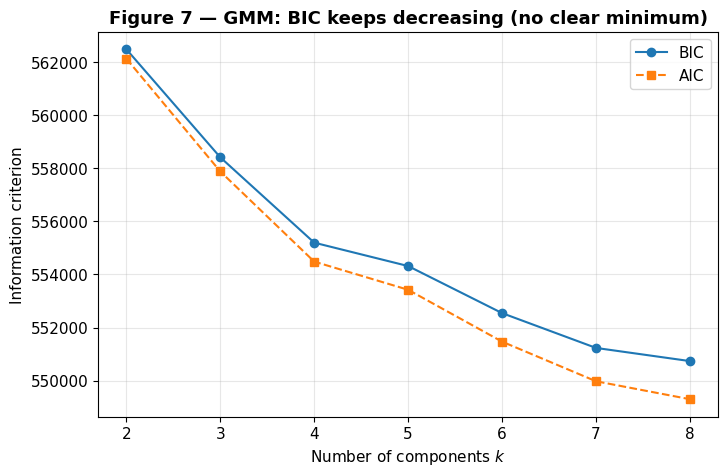

,bic,aic
k,,
2,562482.4,562129.9
3,558411.3,557878.2
4,555196.7,554483.1
5,554315.7,553421.6
6,552543.2,551468.5
7,551232.0,549976.7
8,550736.1,549300.3


In [17]:
gmm_metrics = cu.gmm_selection(X, range(2, 9), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gmm_metrics.index, gmm_metrics["bic"], marker="o", label="BIC")
ax.plot(gmm_metrics.index, gmm_metrics["aic"], marker="s", ls="--", label="AIC")
ax.set_title("Figure 7 — GMM: BIC keeps decreasing (no clear minimum)")
ax.set_xlabel("Number of components $k$"); ax.set_ylabel("Information criterion")
ax.legend()
plt.show()
gmm_metrics.round(1)

**Figure 7.** For a true mixture the BIC curve dips to a clear minimum at the
right number of components. Here BIC (and AIC) **decrease monotonically** across
the whole range — the model can always squeeze out a little more likelihood by
adding another Gaussian to tile the uniform density, but no component count is
genuinely preferred. GMM agrees with K-Means: no discrete structure.

In [18]:
# DBSCAN across a range of eps (min_samples=10). If the data had compact,
# well-separated groups, the cluster count and noise share would be stable in
# eps. We tabulate both to test that directly.
dbscan_rows = []
for eps in [0.3, 0.5, 0.7, 1.0]:
    lbl = DBSCAN(eps=eps, min_samples=10).fit(X).labels_
    n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_noise = int((lbl == -1).sum())
    dbscan_rows.append({"eps": eps, "n_clusters": n_clusters,
                        "noise_points": n_noise,
                        "noise_%": round(100 * n_noise / len(lbl), 1)})
pd.DataFrame(dbscan_rows).set_index("eps")

,n_clusters,noise_points,noise_%
eps,,,
0.3,0,40034,100.0
0.5,5,1233,3.1
0.7,1,0,0.0
1.0,1,0,0.0


**DBSCAN.** The sweep shows the outcome is driven **entirely by `eps`**, not by
any real structure. At `eps=0.3` every point is labelled noise (0 clusters,
100% noise); at `eps=0.5` we get 5 clusters and 3.1% noise; and by `eps=0.7`
everything has merged into a single cluster with no noise at all. There is **no
plateau** — no range of `eps` over which a stable, sensible number of clusters
persists. This is exactly what a region of roughly **uniform density** looks
like: with no sparse valleys separating dense peaks, `eps` alone decides whether
the points are "all noise", "arbitrarily fragmented" or "one big blob".
Density-based clustering therefore also finds no meaningful structure.

**All three algorithm families — centroid-based (K-Means), model-based (GMM) and
density-based (DBSCAN) — agree**, which is the strongest possible support for the
negative conclusion.

<a id="sec10"></a>
## 10. External validation and cluster profiling

We have shown there are no *natural* clusters. But the dataset ships a label,
`EngagementLevel`. Two questions remain:

1. Can clustering the **full** feature space recover that label?
2. If not, **where does the label's signal live**, and can clustering recover it
   there?

We answer both with the **Adjusted Rand Index** (Section&nbsp;2.5), comparing a
$k=3$ K-Means (three clusters for three classes) against `EngagementLevel` under
four feature choices. We fix $k=3$ **solely to match the three known classes for
this label-recovery test** — not as a claim that $k=3$ is a validated cluster
count (Section&nbsp;8 showed none exists). And because ARI is corrected for
chance (expected value $0$ under independent labellings), a value near $0$ means
*no* recovery, not merely weak recovery.

In [19]:
y = df["EngagementLevel"].map({"Low": 0, "Medium": 1, "High": 2}).to_numpy()
ENGAGEMENT_PLANE = ["SessionsPerWeek", "AvgSessionDurationMinutes"]

def ari_for(columns):
    """k=3 K-Means on the given (scaled) columns vs. EngagementLevel."""
    km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(scale(columns))
    return adjusted_rand_score(y, km.labels_), km

ari_full,  km_full  = ari_for(BEHAVIORAL)                               # 5 raw features
ari_plane, km_plane = ari_for(ENGAGEMENT_PLANE)                         # the 2 drivers
ari_total, _        = ari_for(["TotalWeeklyMinutes"])                   # engineered, 1-D
ari_both,  _        = ari_for(BEHAVIORAL + ["TotalWeeklyMinutes"])      # 5 raw + engineered

results = pd.DataFrame({
    "feature set": ["Full behavioural (5 raw)", "Engagement plane (2)",
                    "TotalWeeklyMinutes (1)", "Full + engineered (6)"],
    "ARI vs EngagementLevel": [ari_full, ari_plane, ari_total, ari_both],
}).set_index("feature set")
results.round(4)

,ARI vs EngagementLevel
feature set,
Full behavioural (5 raw),0.0034
Engagement plane (2),0.2147
TotalWeeklyMinutes (1),0.2474
Full + engineered (6),0.2657


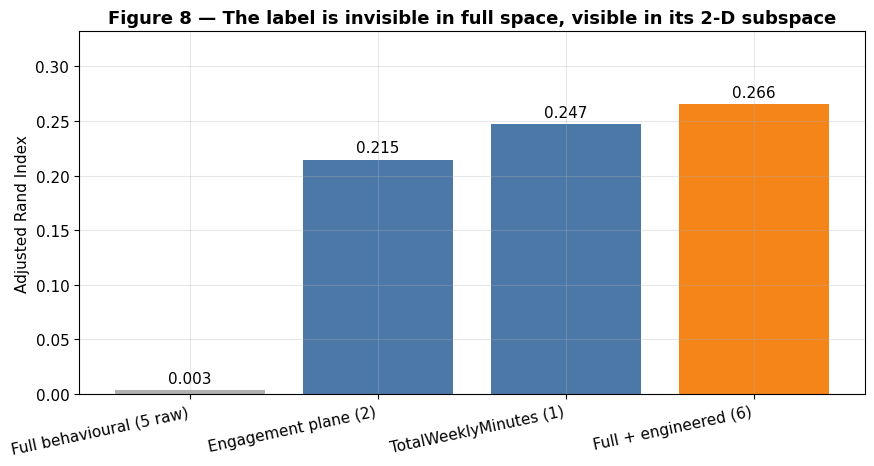

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ["#b0b0b0", "#4c78a8", "#4c78a8", "#f58518"]
bars = ax.bar(results.index, results["ARI vs EngagementLevel"], color=colors)
ax.bar_label(bars, fmt="%.3f", padding=3)
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("Figure 8 — The label is invisible in full space, visible in its 2-D subspace")
ax.set_ylim(0, max(results["ARI vs EngagementLevel"]) * 1.25)
plt.xticks(rotation=12, ha="right")
plt.tight_layout(); plt.show()

**Figure 8 — the centrepiece contrast.**

* **Full behavioural space (5 features): ARI $\approx 0.003$.** Since ARI is
  chance-corrected, $0.003$ means the full-profile clustering recovers
  `EngagementLevel` essentially **not at all**. The three uninformative features
  (`PlayTimeHours`, `PlayerLevel`, `AchievementsUnlocked`) inject noise into the
  Euclidean distance and **drown out** the two informative ones.
* **Engagement plane (2 features): ARI $\approx 0.21$.** Restricting the
  clustering to exactly the two features that define the label recovers real —
  though only partial — agreement (Figure&nbsp;9 shows why it is partial).
* **Engineered `TotalWeeklyMinutes` (1-D): ARI $\approx 0.25$**, and adding it to
  the full set lifts ARI to **$\approx 0.27$**. This is *confirmatory, not a
  discovery*: `TotalWeeklyMinutes` is by construction the product of the two
  label-defining features, so its higher ARI merely verifies that the signal
  lives in those two axes — it is not new structure the algorithm found on its
  own.

The pattern these ARIs reveal is the practical lesson of the project: **signal
confined to a 2-D subspace becomes invisible once it is embedded among
uncorrelated noise dimensions**, because Euclidean distance sums the differences
across *all* axes and the noise dominates the total. Feature selection, not a
fancier clustering algorithm, is what unlocks the signal.

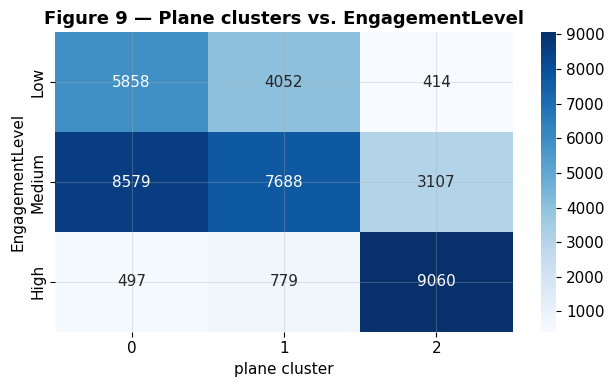

plane cluster,0,1,2
EngagementLevel,,,
Low,5858,4052,414
Medium,8579,7688,3107
High,497,779,9060


In [21]:
# Why is recovery only partial (ARI ≈ 0.21) even in the right subspace?
crosstab = pd.crosstab(df["EngagementLevel"], km_plane.labels_,
                       rownames=["EngagementLevel"], colnames=["plane cluster"]).loc[order]
fig, ax = plt.subplots(figsize=(6.5, 4))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Figure 9 — Plane clusters vs. EngagementLevel")
plt.tight_layout(); plt.show()
crosstab

**Figure 9.** The crosstab explains the *partial* recovery. One cluster is
dominated by **High**-engagement players (about 9060 of 10336), though it also
absorbs ~3100 **Medium** players; the other two carve up the remaining
**Low**+**Medium** mass along a spatial boundary that does **not** line up with
the Low/Medium threshold. `EngagementLevel` is a set of **axis-aligned threshold
bands**, whereas K-Means produces **spherical Voronoi cells** — the geometries
disagree, so even in the right subspace K-Means recovers the label only
partially. This is an important, honest nuance: a high ARI was never going to
happen, because the label is not a *clustering* in the first place.

In [22]:
# Post-hoc profiling of the full-space k=3 clusters (on the ORIGINAL scale).
profile_cols = BEHAVIORAL + ["Age", "TotalWeeklyMinutes"]
profile = cu.cluster_profile(df, km_full.labels_, profile_cols)
display(profile)

# Categorical / binary composition per cluster (profiling, not distance)
print("\nShare of in-game purchasers per full-space cluster:")
print(df.assign(cluster=km_full.labels_)
        .groupby("cluster")["InGamePurchases"].mean().round(3).to_string())

,size,PlayTimeHours,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,Age,TotalWeeklyMinutes
cluster,,,,,,,,
0,12773,18.59,9.20,92.77,33.06,24.91,31.98,852.33
1,14871,11.59,9.56,96.28,79.94,24.99,31.99,919.41
2,12390,5.77,9.65,95.09,30.42,23.57,32.00,918.34



Share of in-game purchasers per full-space cluster:
cluster
0    0.194
1    0.204
2    0.204


**Profiling verdict — and the smoking gun.** Look at *which* features separate
the full-space clusters. They differ almost entirely on **`PlayTimeHours`**
(means ≈ 18.6 / 11.6 / 5.8) and **`PlayerLevel`** (≈ 33 / 80 / 30) — two of the
*noise* features — while the two features that actually define engagement,
`SessionsPerWeek` (≈ 9.5 in every cluster) and `AvgSessionDurationMinutes`
(≈ 95 in every cluster), are **flat across all three clusters**. The purchaser
share is ~0.20 everywhere.

In other words, K-Means carved the uniform cloud along whichever high-spread
directions it happened to seed on, and is **completely blind to the engagement
signal** — which is precisely why the full-space ARI in Figure&nbsp;8 was
$\approx 0$. These are geometric slices of one homogeneous population, not
behavioural personas. This is the correct, honest interpretation and it is fully
consistent with Sections&nbsp;6–9.